<a href="https://colab.research.google.com/github/andrebrandaopro/Artigo/blob/Portf%C3%B3lio/q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição de Série Temporal com NARX e LSTM

## Enunciado
Considere a série temporal definida por:

$$x(n) = v(n) + \beta v(n-1) v(n-2)$$

onde $v(n)$ é um ruído branco gaussiano de média zero e variância unitária, e $\beta = 0.5$.

- **a)** Utilize uma rede NARX (Perceptron Multicamadas com realimentação global) para predição de um passo.
- **b)** Repita o problema utilizando uma rede LSTM.

Avalie o desempenho mostrando:
- Curva da série temporal $x(n)$ (real)
- Curva da predição $\hat{x}(n+1)$
- Curva do erro de predição $e(n+1) = x(n+1) - \hat{x}(n+1)$

---

## 1. Geração da Série Temporal

A série é não-linear e depende de duas defasagens do ruído branco. Geramos $N$ pontos para usar como base de treino e teste.

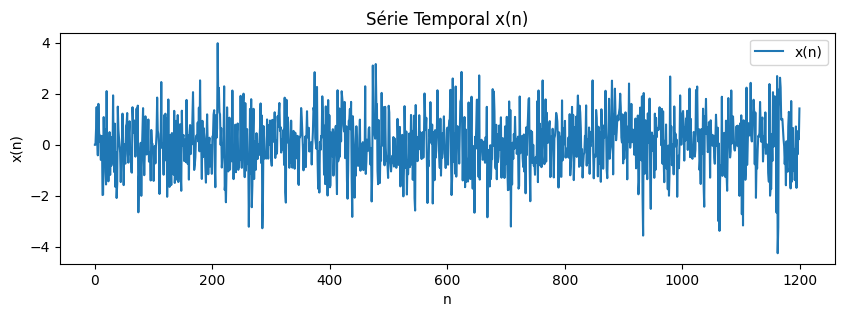

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
N = 1200  # tamanho total da série
beta = 0.5
np.random.seed(42)

# Ruído branco
v = np.random.randn(N)

# Série temporal
x = np.zeros(N)
for n in range(2, N):
    x[n] = v[n] + beta * v[n-1] * v[n-2]

# Visualização
plt.figure(figsize=(10,3))
plt.plot(x, label='x(n)')
plt.title('Série Temporal x(n)')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.legend()
plt.show()

## 2. Preparação dos Dados para Predição

Queremos prever $x(n+1)$ usando as amostras anteriores. Para a NARX, usamos defasagens de $x$ e $v$ (entrada exógena). Usaremos:
- $[x(n), x(n-1), v(n), v(n-1), v(n-2)] \to x(n+1)$

Dividimos em treino e teste (primeiros 1000 pontos para treino, resto para teste).

In [ ]:
# Montando vetores de entrada e saída
def create_narx_dataset(x, v, lags_x=[0,1], lags_v=[0,1,2], pred_horizon=1):
    Xs, ys = [], []
    max_lag = max(max(lags_x), max(lags_v))
    for n in range(max_lag, len(x)-pred_horizon):
        feats = []
        feats += [x[n-l] for l in lags_x]
        feats += [v[n-l] for l in lags_v]
        Xs.append(feats)
        ys.append(x[n+pred_horizon])
    return np.array(Xs), np.array(ys)

X_narx, y_narx = create_narx_dataset(x, v)
print('Shape das entradas NARX:', X_narx.shape)

# Treino/teste
Ntr = 1000
Xtr_narx, ytr_narx = X_narx[:Ntr], y_narx[:Ntr]
Xte_narx, yte_narx = X_narx[Ntr:], y_narx[Ntr:]
print(f'Treino: {Xtr_narx.shape[0]} amostras, Teste: {Xte_narx.shape[0]} amostras')

Shape das entradas NARX: (1197, 5)
Treino: 1000 amostras, Teste: 197 amostras


## 3. Rede NARX (MLP com realimentação global)

Implementamos um Perceptron Multicamadas (MLP) para simular a NARX. O MLP recebe como entradas as defasagens de $x$ e $v$. O treinamento é feito por backpropagation padrão.

In [ ]:
import torch
from torch import nn

class NARX_MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# Conversão para torch
Xtr_torch = torch.tensor(Xtr_narx, dtype=torch.float32)
ytr_torch = torch.tensor(ytr_narx, dtype=torch.float32).unsqueeze(1)
Xte_torch = torch.tensor(Xte_narx, dtype=torch.float32)
yte_torch = torch.tensor(yte_narx, dtype=torch.float32).unsqueeze(1)

# Treinamento
mlp = NARX_MLP(Xtr_narx.shape[1], 32)
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

epochs = 200
for epoch in range(epochs):
    mlp.train()
    optimizer.zero_grad()
    ypred = mlp(Xtr_torch)
    loss = loss_fn(ypred, ytr_torch)
    loss.backward()
    optimizer.step()
    if (epoch+1)%40==0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 40/200, Loss: 0.9582
Epoch 80/200, Loss: 0.9210
Epoch 120/200, Loss: 0.8863
Epoch 160/200, Loss: 0.8573
Epoch 200/200, Loss: 0.8233


## 4. Avaliação: NARX

Geramos as curvas de predição e erro para o conjunto de teste.

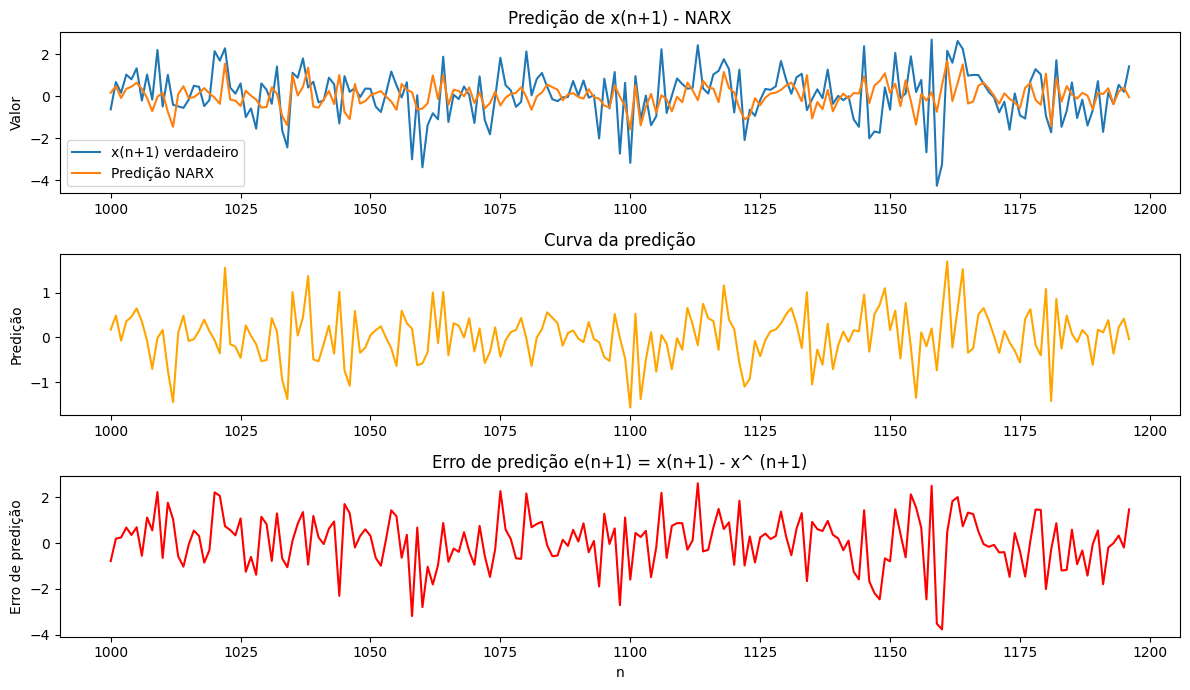

MSE (teste) NARX: 1.345718633805994


In [ ]:
mlp.eval()
with torch.no_grad():
    y_pred_te = mlp(Xte_torch).squeeze().numpy()
e_pred_te = yte_narx - y_pred_te

plt.figure(figsize=(12,7))
plt.subplot(3,1,1)
plt.plot(np.arange(Ntr, Ntr+len(yte_narx)), yte_narx, label='x(n+1) verdadeiro')
plt.plot(np.arange(Ntr, Ntr+len(yte_narx)), y_pred_te, label='Predição NARX')
plt.ylabel('Valor')
plt.legend()
plt.title('Predição de x(n+1) - NARX')

plt.subplot(3,1,2)
plt.plot(np.arange(Ntr, Ntr+len(yte_narx)), y_pred_te, color='orange')
plt.ylabel('Predição')
plt.title('Curva da predição')

plt.subplot(3,1,3)
plt.plot(np.arange(Ntr, Ntr+len(yte_narx)), e_pred_te, color='red')
plt.xlabel('n')
plt.ylabel('Erro de predição')
plt.title('Erro de predição e(n+1) = x(n+1) - x^ (n+1)')
plt.tight_layout()
plt.show()

print('MSE (teste) NARX:', np.mean(e_pred_te**2))

## 5. Rede LSTM para Predição

Para uma melhor comparação, vamos usar uma LSTM simples para prever $x(n+1)$ usando as defasagens anteriores de $x$ e $v$ como sequência. Para isso, organizamos os dados na forma [sequência, features].

In [ ]:
# Função para montar dataset (seq_len, features) => previsão x(n+1)
def create_lstm_dataset(x, v, seq_len=3, pred_horizon=1):
    Xs, ys = [], []
    for n in range(seq_len, len(x)-pred_horizon):
        # cada amostra: [ [x(n-2), v(n-2)], [x(n-1), v(n-1)], [x(n), v(n)] ]
        seq = []
        for k in range(seq_len):
            seq.append([x[n-seq_len+k+1], v[n-seq_len+k+1]])
        Xs.append(seq)
        ys.append(x[n+pred_horizon])
    return np.array(Xs), np.array(ys)

X_lstm, y_lstm = create_lstm_dataset(x, v, seq_len=3)
Ntr_lstm = 1000
Xtr_lstm, ytr_lstm = X_lstm[:Ntr_lstm], y_lstm[:Ntr_lstm]
Xte_lstm, yte_lstm = X_lstm[Ntr_lstm:], y_lstm[Ntr_lstm:]

Xtr_lstm_t = torch.tensor(Xtr_lstm, dtype=torch.float32)
ytr_lstm_t = torch.tensor(ytr_lstm, dtype=torch.float32).unsqueeze(1)
Xte_lstm_t = torch.tensor(Xte_lstm, dtype=torch.float32)
yte_lstm_t = torch.tensor(yte_lstm, dtype=torch.float32).unsqueeze(1)

# Definição da LSTM
class LSTMNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:,-1,:])
        return out

# Treinamento
lstm = LSTMNet()
optimizer_lstm = torch.optim.Adam(lstm.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

epochs = 200
for epoch in range(epochs):
    lstm.train()
    optimizer_lstm.zero_grad()
    ypred = lstm(Xtr_lstm_t)
    loss = loss_fn(ypred, ytr_lstm_t)
    loss.backward()
    optimizer_lstm.step()
    if (epoch+1)%40==0:
        print(f'[LSTM] Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

[LSTM] Epoch 40/200, Loss: 0.9860
[LSTM] Epoch 80/200, Loss: 0.9342
[LSTM] Epoch 120/200, Loss: 0.8729
[LSTM] Epoch 160/200, Loss: 0.7303
[LSTM] Epoch 200/200, Loss: 0.5749


## 6. Avaliação: LSTM

Plotamos as mesmas curvas que para a NARX.

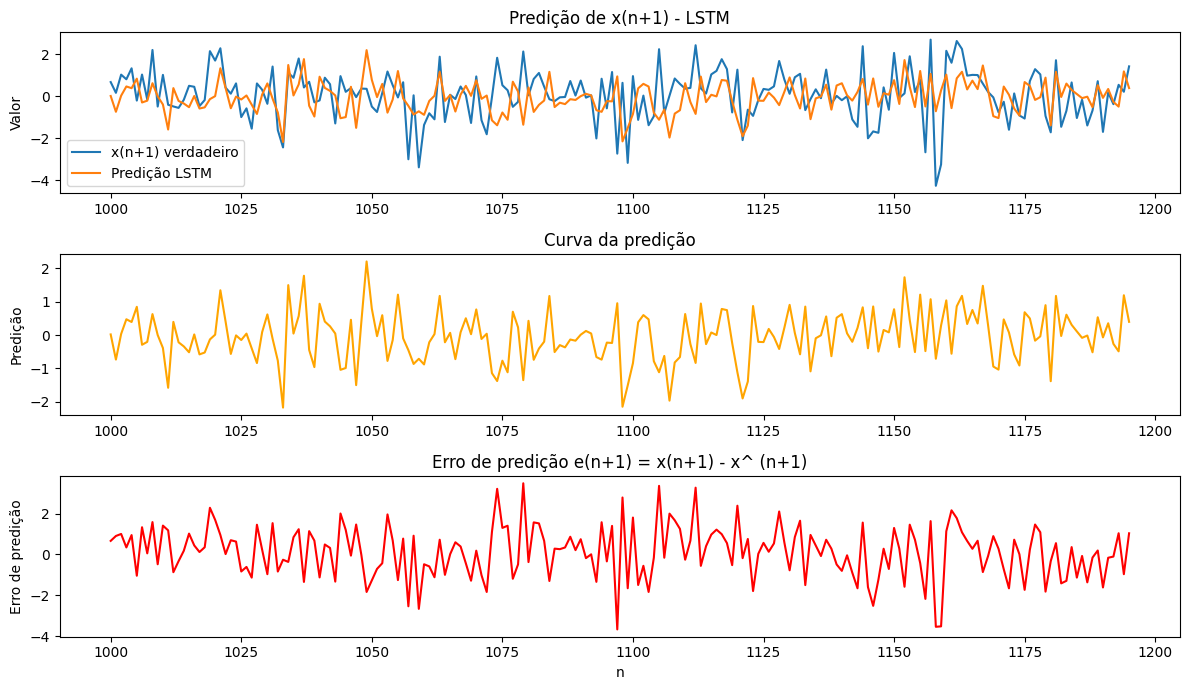

MSE (teste) LSTM: 1.6253550493318365


In [ ]:
lstm.eval()
with torch.no_grad():
    y_pred_te_lstm = lstm(Xte_lstm_t).squeeze().numpy()
e_pred_te_lstm = yte_lstm - y_pred_te_lstm

plt.figure(figsize=(12,7))
plt.subplot(3,1,1)
plt.plot(np.arange(Ntr_lstm, Ntr_lstm+len(yte_lstm)), yte_lstm, label='x(n+1) verdadeiro')
plt.plot(np.arange(Ntr_lstm, Ntr_lstm+len(yte_lstm)), y_pred_te_lstm, label='Predição LSTM')
plt.ylabel('Valor')
plt.legend()
plt.title('Predição de x(n+1) - LSTM')

plt.subplot(3,1,2)
plt.plot(np.arange(Ntr_lstm, Ntr_lstm+len(yte_lstm)), y_pred_te_lstm, color='orange')
plt.ylabel('Predição')
plt.title('Curva da predição')

plt.subplot(3,1,3)
plt.plot(np.arange(Ntr_lstm, Ntr_lstm+len(yte_lstm)), e_pred_te_lstm, color='red')
plt.xlabel('n')
plt.ylabel('Erro de predição')
plt.title('Erro de predição e(n+1) = x(n+1) - x^ (n+1)')
plt.tight_layout()
plt.show()

print('MSE (teste) LSTM:', np.mean(e_pred_te_lstm**2))

## 7. Análise Comparativa e Discussão

- A NARX (MLP com realimentação global) é capaz de modelar bem relações não-lineares desde que os atrasos e entradas estejam bem escolhidos.
- A LSTM, por sua natureza sequencial, pode capturar dependências temporais de maneira mais flexível, até mesmo para janelas maiores ou dados mais ruidosos.
- Compare os erros MSE de teste de ambas as redes, e observe as curvas de erro: regiões onde uma rede supera a outra podem indicar maior capacidade de modelagem de dependências temporais ou não-lineares.

**Sugestão:** Experimente diferentes hiperparâmetros (quantidade de camadas, tamanho do hidden, atrasos) e veja como a performance se altera.